# Optics Project
*Interns:* Carissa Kiehl, Max Sullivan, Ahmir Postell, Ashi Poorey, Samriddhi Bhatia

We measure the effect of different currents (and therefore different magnetic field strengths) on the fluorescence in an NV center experiment.

In [1]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import pandas as pd
from scipy.signal import find_peaks
from scipy.optimize import curve_fit

In [2]:
df25 = pd.read_excel('25_mA.xlsx',skiprows=1) 
df50 = pd.read_excel('50_mA.xlsx',skiprows=1) 
df75 = pd.read_excel('75_mA.xlsx',skiprows=1) 
dfNone = pd.read_excel('no_current.xlsx',skiprows=1) 
headers =  ["int","signal"]
df25.columns = headers
df50.columns = headers
df75.columns = headers
dfNone.columns = headers

# to GHz
start_freq = 2.82e9  # Hz
step = 2e6           # Hz per step
for df in [df25, df50, df75, dfNone]:
    df['freq_GHz'] = (start_freq + df.index * step) / 1e9

### Double Gaussian Fit
Use curve_fit to fit two Gaussians to data. The two Gaussians show the two peaks that emerge in the fluorescence data when a magnetic field is present.

In [3]:
# double Gaussian
def double_gaussian(x, a1, x01, sigma1, a2, x02, sigma2, c):
    g1 = a1 * np.exp(-(x - x01)**2 / (2 * sigma1**2))
    g2 = a2 * np.exp(-(x - x02)**2 / (2 * sigma2**2))
    return g1 + g2 + c

# Intial guesses for curvefit
a1 = .01
a2 = .01
x01 = 2.865
x02 = 2.875
sigma1 = .01
sigma2 = .01
c = 0
params = [a1,x01,sigma1,a2,x02,sigma2,c] 

# curvefit
popt25, pcov25 = curve_fit(double_gaussian, df25['freq_GHz'], df25['signal'], params)
popt50, pcov50 = curve_fit(double_gaussian, df50['freq_GHz'], df50['signal'], params)
popt75, pcov75 = curve_fit(double_gaussian, df75['freq_GHz'], df75['signal'], params)
poptNone, pcovNone = curve_fit(double_gaussian, dfNone['freq_GHz'], dfNone['signal'], params)

# y fits
yfit25 = double_gaussian(df25['freq_GHz'],*popt25)
yfit50 = double_gaussian(df50['freq_GHz'],*popt50)
yfit75 = double_gaussian(df75['freq_GHz'],*popt75)
yfitNone = double_gaussian(dfNone['freq_GHz'],*poptNone)

# capture uncertainties in fit
#[da1, dx01, dsigma1, da2, dx02, dsigma2, dc] = np.sqrt(np.diag(pcov25))

### Plot Fluorescence Data
Plot experimental data to curve_fit output. Also plot peak position

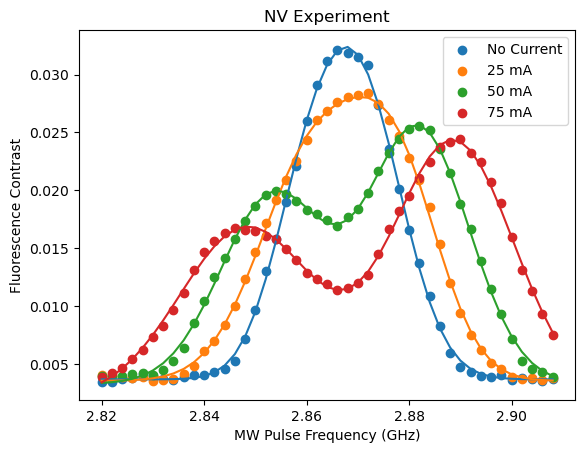

In [4]:
# Plot data with fitted lines
plt.scatter(dfNone['freq_GHz'],dfNone['signal'],label="No Current")
plt.plot(dfNone['freq_GHz'],yfitNone)

plt.scatter(df25['freq_GHz'],df25['signal'],label="25 mA")
plt.plot(df25['freq_GHz'],yfit25)

plt.scatter(df50['freq_GHz'],df50['signal'],label="50 mA")
plt.plot(df50['freq_GHz'],yfit50)

plt.scatter(df75['freq_GHz'],df75['signal'],label="75 mA")
plt.plot(df75['freq_GHz'],yfit75)

# Find peaks
peaks25, properties25 = find_peaks(yfit25, height=0.005, distance=None)
peaks50, properties50 = find_peaks(yfit50, height=0.005, distance=None)
peaks75, properties75 = find_peaks(yfit75, height=0.005, distance=None)
peaksNone, propertiesNone = find_peaks(yfitNone, height=0.005, distance=None)

# Plot peaks
peaksNone = (start_freq + step * peaksNone) / 1e9
peaks25 = (start_freq + step * peaks25) / 1e9
peaks50 = (start_freq + step * peaks50) / 1e9
peaks75 = (start_freq + step * peaks75) / 1e9
#plt.plot(peaksNone, yfitNone[peaksNone], "x")
#plt.plot(peaks25, yfit25[peaks25], "x")
#plt.plot(peaks50, yfit50[peaks50], "x")
#plt.plot(peaks75, yfit75[peaks75], "x")

# Label graph
plt.ylabel("Fluorescence Contrast")
plt.xlabel("MW Pulse Frequency (GHz)")
plt.title("NV Experiment")
plt.legend()
plt.show()

In [5]:
print("25 mA fitted peak location (1):",popt25[1])
print("25 mA fitted peak location (2):",popt25[4])
print("25 mA find_peaks (1):",peaks25[0])

print("\n50 mA fitted peak location (1):",popt50[1])
print("50 mA fitted peak location (2):",popt50[4])
print("50 mA find_peaks (1):",peaks50[0])
print("50 mA find_peaks (2):",peaks50[1])

print("\n75 mA fitted peak location:",popt75[1])
print("75 mA fitted peak location:",popt75[4])
print("75 mA find_peaks (1):",peaks75[0])
print("75 mA find_peaks (2):",peaks75[1])

print("\nNo current fitted peak location (1):",poptNone[1])
print("No current fitted peak location (2):",poptNone[4])
print("No current find_peaks (1):",peaksNone[0])

25 mA fitted peak location (1): 2.8616307856454983
25 mA fitted peak location (2): 2.8779229824794785
25 mA find_peaks (1): 2.87

50 mA fitted peak location (1): 2.8534812136345415
50 mA fitted peak location (2): 2.881864848876536
50 mA find_peaks (1): 2.854
50 mA find_peaks (2): 2.882

75 mA fitted peak location: 2.84834180280512
75 mA fitted peak location: 2.888662521992422
75 mA find_peaks (1): 2.848
75 mA find_peaks (2): 2.888

No current fitted peak location (1): 2.8593626629978632
No current fitted peak location (2): 2.8704959051168952
No current find_peaks (1): 2.868


### Plot Current vs Peak Separation

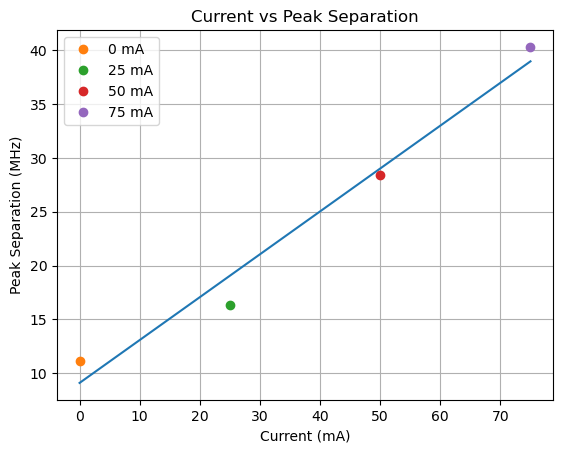

In [6]:
# Plot current vs peak location
diff25 = (popt25[4] - popt25[1])*1000
diff50 = (popt50[4] - popt50[1])*1000
diff75 = (popt75[4] - popt75[1])*1000
diffNone = (poptNone[4] - poptNone[1])*1000

# lienar fit
def linear(x, m, b):
    return m*x + b
m = 1
b = 0
params1 = [m,b]

popt1, pcov1 = curve_fit(linear, [0,25,50,75], [diffNone, diff25, diff50, diff75], params1)
frange = np.linspace(0,75)
plt.plot(frange,linear(frange,*popt1))

plt.plot(0, diffNone, 'o', label = "0 mA")
plt.plot(25, diff25, 'o', label = "25 mA")
plt.plot(50, diff50, 'o', label = "50 mA")
plt.plot(75, diff75, 'o', label = "75 mA")
plt.title("Current vs Peak Separation")
plt.xlabel("Current (mA)")
plt.ylabel("Peak Separation (MHz)")
plt.grid()
plt.legend()
plt.show()

### Plot Magnetic Field vs Peak Separation

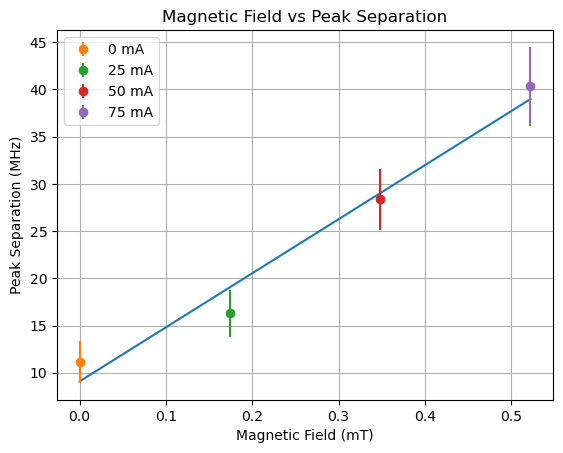

NV center gyromagnetic ratio (γ): 28 GHz/T
2γ: 56 GHz/T
Fit slope: 57.24397655612285 ± 6.797147926605215 GHz/T


In [7]:
# B field calculations: https://www.accelinstruments.com/Magnetic/Magnetic-field-calculator.html
# Parameters: 
#Coil Inner Radius (mm): 15.5
#Coil Length (mm): 20
#Copper Wire Diameter with Insulation (mm): 0.53
#Copper Wire Diameter without Insulation (mm): 0.52
#Number of Turns: 400 (+/- 20?? -> or 5%)
#Coil Current (A): *varries*
#Frequency (kHz): 0
#Distance from center (mm): 3
#Core Relative Permeability, k: 1
#Winding Compactness Factor: 0.9

# Results:
# 0 A: 0 mT
# 25 A: 0.3013 mT
# 50 A: 0.6025 mT
# 75 A: 0.9038 mT

B0 = 0
B25 = 0.3013
B50 = 0.6025
B75 = 0.9038
BVals = np.array([B0,B25,B50,B75])  # in mT
PeakVals = np.array([diffNone, diff25, diff50, diff75])  # in MHz

# these are unaligned NV centers; convert by factor of sin(35.3 degrees)
BVals = BVals*np.sin(np.radians(35.3))

popt2, pcov2 = curve_fit(linear, BVals, PeakVals, params1)
frange2 = np.linspace(0,BVals[3])
plt.plot(frange2,linear(frange2,*popt2))

# capture values
[m, b] = popt2

# capture uncertainties
[dm,db] = np.sqrt(np.diag(pcov2))

# propogate error to y values (y = mx+b)
y_errors = np.sqrt((BVals * dm)**2 + db**2)

# Plot with error bars
#plt.errorbar(BVals, PeakVals, yerr=y_errors, fmt='o', label="Data + error")

plt.errorbar(BVals[0], diffNone, yerr=y_errors[0], fmt='o', label = "0 mA")
plt.errorbar(BVals[1], diff25, yerr=y_errors[1], fmt='o', label = "25 mA")
plt.errorbar(BVals[2], diff50, yerr=y_errors[2], fmt='o', label = "50 mA")
plt.errorbar(BVals[3], diff75, yerr=y_errors[3], fmt='o', label = "75 mA")

plt.title("Magnetic Field vs Peak Separation")
plt.xlabel("Magnetic Field (mT)")
plt.ylabel("Peak Separation (MHz)")
plt.grid()
plt.legend()
plt.show()

print("NV center gyromagnetic ratio (γ):",28,"GHz/T")
print("2γ:",2*28,"GHz/T")
print("Fit slope:",m,"±",dm,"GHz/T")

### Rabi Oscillations Length
We vary the microwave pulse length to determine the Rabi frequency. The maximum RF amplitude is 1 V.

In [8]:
dfRabi = pd.read_excel('Rabi_length_scan.xlsx',skiprows=1) 
headersRabi =  ["int","signal"]
dfRabi.columns = headersRabi

# to ns
start_ns = 20 # ns
step_ns = 20 # ns per step
dfRabi['ns_step'] = (start_ns + dfRabi.index * step_ns)

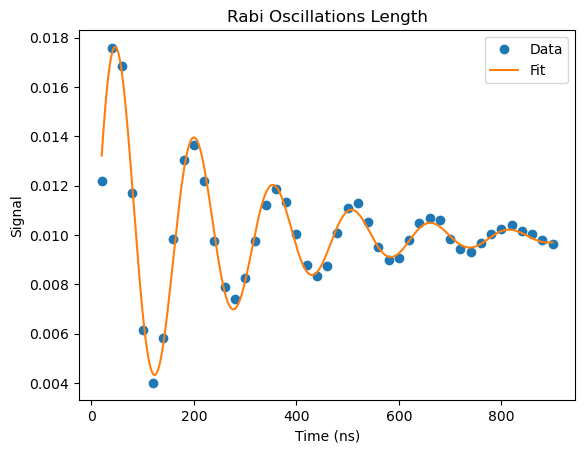

Angular Frequency: 42.839899821679 rad/μs
Frequency: 6.818181818181818 MHz
Period: 146.66666666666669 ns


In [9]:
t_data = dfRabi['ns_step'].values * 1e-9  # s
y_data = dfRabi['signal'].values
estimated_periods = 6
data_span = t_data.max() - t_data.min()

# deacying sinusoidal fit
def sinusoid(t, A, tau, omega, phi, c):
    return A * np.exp(-t / tau) * np.sin(omega * t + phi) + c
A = .02
tau = 200 * 1e-9 # s
omega = 2 * np.pi * estimated_periods / data_span # Hz # initial guess so it doesn't overfit
phi = 0
c = .01
paramsRabi = [A,tau,omega,phi,c]

poptRabi, pcovRabi = curve_fit(sinusoid, t_data, y_data, paramsRabi)

# Smooth time range for plotting
frangeRabi = np.linspace(t_data.min(), t_data.max(), 1000)
plt.plot(t_data * 1e9, y_data, 'o', label='Data')  # plot back in ns
plt.plot(frangeRabi * 1e9, sinusoid(frangeRabi, *poptRabi), '-', label='Fit')
plt.title('Rabi Oscillations Length')
plt.xlabel('Time (ns)')
plt.ylabel('Signal')
plt.legend()
plt.show()

print("Angular Frequency:", omega*1e-6, "rad/μs")
print("Frequency:", (omega*1e-6)/(2*np.pi), "MHz")
print("Period:", (2*np.pi/(omega))*1e9, "ns")

### Rabi Oscillations Amplitude
We vary microwave pulse amplitude at a set pulse length of 300 ns.

In [10]:
dfAmp = pd.read_excel('Rabi_amplitude_scan.xlsx',skiprows=1) 
headersAmp =  ["int","signal"]
dfAmp.columns = headersRabi

# to mV
start_mV = 1 # mV
step_mV = 18 # mV per step
dfAmp['mV_step'] = (start_mV + dfAmp.index * step_mV)

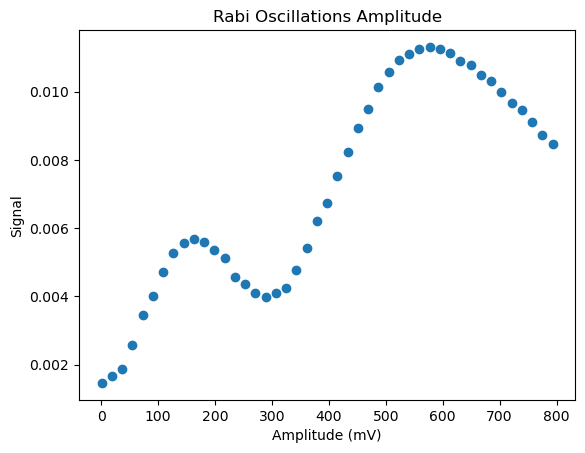

Peaks: 163 577 mV


In [11]:
plt.plot(dfAmp['mV_step'], dfAmp['signal'], 'o')  
plt.title('Rabi Oscillations Amplitude')
plt.xlabel('Amplitude (mV)')
plt.ylabel('Signal')
#plt.legend()
plt.show()

peaksAmp, propertiesAmp = find_peaks(dfAmp['signal'], height=0.004, distance=None)
peaksAmp = (start_mV + step_mV * peaksAmp) 
print("Peaks:",peaksAmp[0],peaksAmp[1],"mV")